# import Libraries

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [63]:
#loading dataset
path = r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTrain+.txt"
df = pd.read_csv(path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Add column names

In [64]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Handling missing values

In [65]:
print(df.isnull().sum().sum(), "missing values.")

df = df.dropna()

0 missing values.


# Remove duplicates

In [66]:
removed = df.duplicated().sum()
df = df.drop_duplicates()

print(f"Removed {removed} duplicate rows.")


Removed 0 duplicate rows.


# encoded categorical features

In [67]:
cols = ['protocol_type', 'service', 'flag']
df = pd.get_dummies(df, columns=cols)
df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


# scale numerical features

In [68]:
x= MinMaxScaler()
numeric= df.drop(columns=['label']).columns

df[numeric] = x.fit_transform(df[numeric])
df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


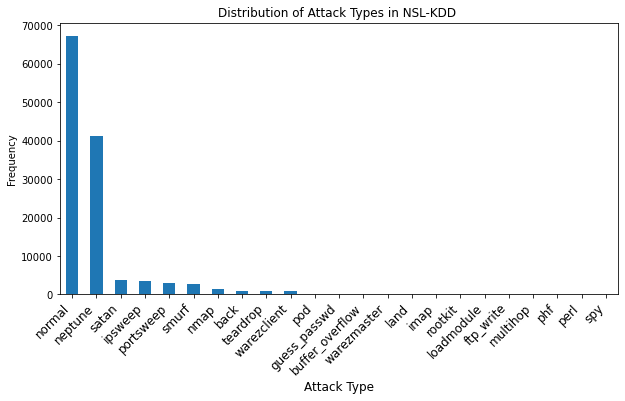

In [69]:
df['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Attack Types in NSL-KDD ")
plt.xlabel("Attack Type",fontsize=12)
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.show()


In [70]:
#Mapping attacks into categories
attack_categories = {
    'normal': 'Normal',
    # DoS
    'back': 'DoS','land': 'DoS','neptune': 'DoS','pod': 'DoS','smurf': 'DoS','teardrop': 'DoS',
    'mailbomb': 'DoS','apache2': 'DoS','processtable': 'DoS','udpstorm': 'DoS',
    # Probe
    'satan': 'Probe','ipsweep': 'Probe','nmap': 'Probe','portsweep': 'Probe',
    'mscan': 'Probe','saint': 'Probe',
    # U2R
    'buffer_overflow': 'U2R','loadmodule': 'U2R','perl': 'U2R','rootkit': 'U2R',
    'xterm': 'U2R','ps': 'U2R','sqlattack': 'U2R','httptunnel': 'U2R',
    # R2L
    'ftp_write': 'R2L','guess_passwd': 'R2L','imap': 'R2L','multihop': 'R2L',
    'phf': 'R2L','spy': 'R2L','warezclient': 'R2L','warezmaster': 'R2L',
    'sendmail': 'R2L','named': 'R2L','snmpgetattack': 'R2L','snmpguess': 'R2L',
    'worm': 'R2L','xlock': 'R2L','xsnoop': 'R2L'
}
     

In [71]:
# create a new column
df['category'] = df['label'].map(attack_categories)
print(df['category'].value_counts())

Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: category, dtype: int64


C:\Users\Hp\AppData\Local\Temp/ipykernel_21816/3098579446.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df['category'] = df['label'].map(attack_categories)


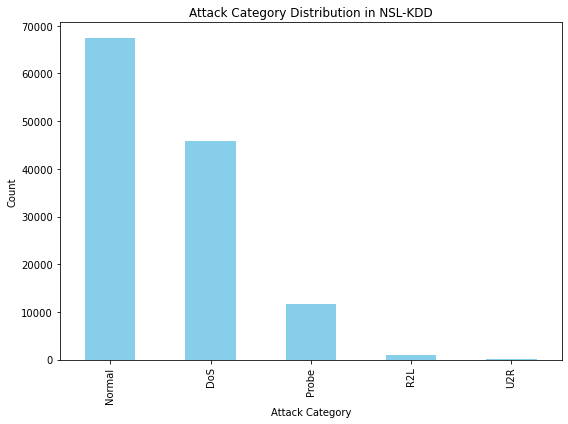

In [72]:
#Plot bar chart for categories
plt.figure(figsize=(8,6))
df['category'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.title('Attack Category Distribution in NSL-KDD')
plt.tight_layout()
plt.show()


# Identify categorical vs. numerical features

In [73]:
categorical = df.select_dtypes(include=['object']).columns.tolist()
numerical= df.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", categorical)
print("Numerical Features:", numerical)

Categorical Features: ['label', 'category']
Numerical Features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty_level', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_da

# Create a schema mapping table

In [74]:
#Create a schema mapping table
binary = {"land","logged_in","root_shell","su_attempted","is_host_login","is_guest_login"}
schema=[]
for col in df.columns:
    if col in categorical:
        schema.append([col, "Categorical", "One-Hot Encode", "Network/Connection"])
    elif col in binary:
        schema.append([col, "Binary", "Keep as-is", "Behavior/Privilege"])
    elif col == "level":
        schema.append([col, "Target", "Map to Attack/Normal", "Class Level"])
    else:
        schema.append([col, "Numerical", "Normalize/Standardize", "Traffic/Statistical"])
schema_df = pd.DataFrame(schema, columns=["Feature Name", "Type", "Preprocessing Action", "Semantic Category"])
display(schema_df.head(15))

,Feature Name,Type,Preprocessing Action,Semantic Category
0,duration,Numerical,Normalize/Standardize,Traffic/Statistical
1,src_bytes,Numerical,Normalize/Standardize,Traffic/Statistical
2,dst_bytes,Numerical,Normalize/Standardize,Traffic/Statistical
3,land,Binary,Keep as-is,Behavior/Privilege
4,wrong_fragment,Numerical,Normalize/Standardize,Traffic/Statistical
5,urgent,Numerical,Normalize/Standardize,Traffic/Statistical
6,hot,Numerical,Normalize/Standardize,Traffic/Statistical
7,num_failed_logins,Numerical,Normalize/Standardize,Traffic/Statistical
8,logged_in,Binary,Keep as-is,Behavior/Privilege
9,num_compromised,Numerical,Normalize/Standardize,Traffic/Statistical


In [75]:
#Identify and handle missing values in NSL-KDD dataset
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(data[col].mode()[0], inplace=True)
        else:
            df[col].fillna(data[col].median(), inplace=True)
print("Missing values handled.")
     

Missing values handled.


In [76]:
#Remove Duplicate Rows
df = df.drop_duplicates()
print("Duplicates removed. Current shape:", df.shape)

Duplicates removed. Current shape: (125973, 125)


# ML algorithms

1. Supervised Learning

2. Unsupervised Learning

3. Semi-Supervised Learning

4. Reinforcement Learning

5. Ensemble Learning

# Practice with simple examples
## predicting house prices:


In [77]:
# import linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = {
    'Size(sqft)': [750, 800, 1200, 1500, 1800, 2000],
    'Bedrooms': [2, 2, 3, 3, 4, 4],
    'Age': [10, 15, 20, 5, 8, 12],
    'Price': [150000, 160000, 200000, 250000, 300000, 320000]
}

df = pd.DataFrame(data)

# Features and target
X = df[['Size(sqft)', 'Bedrooms', 'Age']]
y = df['Price']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
print("Predicted Prices:", y_pred)
print("Mean Squared Error:", mse)

# Predict price for a new house
new_house = [[1600, 3, 10]]  # Size=1600 sqft, 3 bedrooms, Age=10 years
predicted_price = model.predict(new_house)
print("Predicted Price for new house:", predicted_price[0])


Predicted Prices: [138809.52380952 140000.        ]
Mean Squared Error: 262613378.684809
Predicted Price for new house: 257142.85714285713


## Customer segmentation :

   CustomerID  AnnualIncome(k$)  SpendingScore  Cluster
0           1                15             39        0
1           2                16             81        1
2           3                45              6        0
3           4                55             77        1
4           5                85             40        2
5           6                90             76        2
6           7               120             20        2
7           8               130             94        2


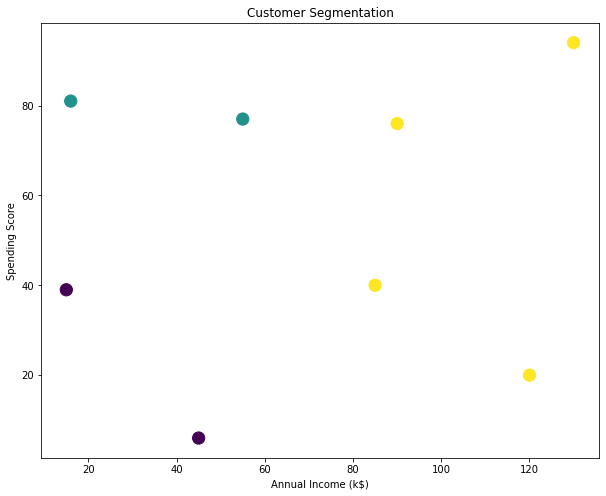

In [78]:
from sklearn.cluster import KMeans
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8],
    'AnnualIncome(k$)': [15, 16, 45, 55, 85, 90, 120, 130],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 20, 94]
}

df = pd.DataFrame(data)

# Features for clustering
X = df[['AnnualIncome(k$)', 'SpendingScore']]

# Create K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Assign clusters to data
df['Cluster'] = kmeans.labels_

print(df)
plt.figure(figsize=(10, 8))
plt.scatter(df['AnnualIncome(k$)'], df['SpendingScore'], c=df['Cluster'], cmap='viridis',s=150)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')
plt.show()

## Implement Data loading, initial exploration, handling missing data, feature scaling, train_test split.

### Data loading:

In [79]:
import pandas as pd

# Load dataset
path = r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTrain+.txt"
df = pd.read_csv(path, header=None)
print("Dataset loaded successfully!")
print(df.head())


Dataset loaded successfully!
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


### Initial Exploration

In [80]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  


In [81]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
                 0             4             5              6              7   \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000  125973.000000   
mean      287.14465  4.556674e+04  1.977911e+04       0.000198       0.022687   
std      2604.51531  5.870331e+06  4.021269e+06       0.014086       0.253530   
min         0.00000  0.000000e+00  0.000000e+00       0.000000       0.000000   
25%         0.00000  0.000000e+00  0.000000e+00       0.000000       0.000000   
50%         0.00000  4.400000e+01  0.000000e+00       0.000000       0.000000   
75%         0.00000  2.760000e+02  5.160000e+02       0.000000       0.000000   
max     42908.00000  1.379964e+09  1.309937e+09       1.000000       3.000000   

                  8              9              10             11  \
count  125973.000000  125973.000000  125973.000000  125973.000000   
mean        0.000111       0.204409       0.001222       0.395736   
std         0.014366       2.149968       

In [82]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
dtype: int64


### Handling Missing Data

In [83]:
data_cleaned = df.dropna()
print("Shape after handling missing values:", data_cleaned.shape)

Shape after handling missing values: (125973, 43)


### Feature Scaling

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeature scaling completed.")


Feature scaling completed.


### Train-test split :

In [85]:

X_b = df.iloc[:, :-2]  # all columns except last two
y_b = df.iloc[:, 41]
# Encode categorical features
for col in [1, 2, 3]:  
    le = LabelEncoder()
    X_b.iloc[:, col] = le.fit_transform(X_b.iloc[:, col])

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.3, random_state=42, stratify=y_b
)

print("Training set shape:", X_b_train.shape)
print("Testing set shape:", X_b_test.shape)




Training set shape: (88181, 41)
Testing set shape: (37792, 41)


In [86]:
#import logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Scale the features
scaler = StandardScaler()
X_b_train_scaled = scaler.fit_transform(X_b_train)
X_b_test_scaled = scaler.transform(X_b_test)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")
lr.fit(X_b_train_scaled, y_b_train)

# Predictions
y_b_pred_lr = lr.predict(X_b_test_scaled)

# Evaluation
accuracy = accuracy_score(y_b_test, y_b_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_lr, zero_division=0))


Logistic Regression Accuracy: 94.21%
                 precision    recall  f1-score   support

           back       0.79      0.99      0.88       287
buffer_overflow       0.05      0.67      0.10         9
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.84      1.00      0.91        16
           imap       0.07      1.00      0.14         3
        ipsweep       0.88      0.97      0.92      1080
           land       0.71      1.00      0.83         5
     loadmodule       0.00      0.00      0.00         3
       multihop       0.01      0.50      0.03         2
        neptune       1.00      1.00      1.00     12364
           nmap       0.56      0.95      0.70       448
         normal       1.00      0.90      0.95     20203
           perl       0.50      1.00      0.67         1
            phf       0.50      1.00      0.67         1
            pod       0.97      1.00      0.98        60
      portsweep       0.90      0.99      0.94    

In [87]:
# Random Forest Classifier
from sklearn.metrics import classification_report
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_b_train, y_b_train)

y_b_pred_rf = rf.predict(X_b_test)
accuracy=accuracy_score(y_b_test, y_b_pred_rf)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_rf, zero_division=0))
     

Random Forest Accuracy: 99.83%
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       287
buffer_overflow       1.00      0.89      0.94         9
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      0.94      0.97        16
           imap       1.00      1.00      1.00         3
        ipsweep       1.00      0.99      0.99      1080
           land       0.67      0.80      0.73         5
     loadmodule       0.00      0.00      0.00         3
       multihop       0.00      0.00      0.00         2
        neptune       1.00      1.00      1.00     12364
           nmap       0.98      1.00      0.99       448
         normal       1.00      1.00      1.00     20203
           perl       1.00      1.00      1.00         1
            phf       0.00      0.00      0.00         1
            pod       1.00      0.98      0.99        60
      portsweep       1.00      1.00      1.00       879

In [88]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_res = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=None)
dt_res.fit(X_b_train, y_b_train)

y_b_pred_dt = dt_res.predict(X_b_test)
accuracy=accuracy_score(y_b_test, y_b_pred_dt)
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_b_test, y_b_pred_dt,zero_division=0))

Decision Tree Accuracy: 99.75%
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       287
buffer_overflow       0.55      0.67      0.60         9
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      1.00      1.00        16
           imap       1.00      0.67      0.80         3
        ipsweep       1.00      0.99      0.99      1080
           land       0.60      0.60      0.60         5
     loadmodule       0.00      0.00      0.00         3
       multihop       0.00      0.00      0.00         2
        neptune       1.00      1.00      1.00     12364
           nmap       0.98      1.00      0.99       448
         normal       1.00      1.00      1.00     20203
           perl       1.00      1.00      1.00         1
            phf       0.00      0.00      0.00         1
            pod       1.00      0.98      0.99        60
      portsweep       1.00      1.00      1.00       879

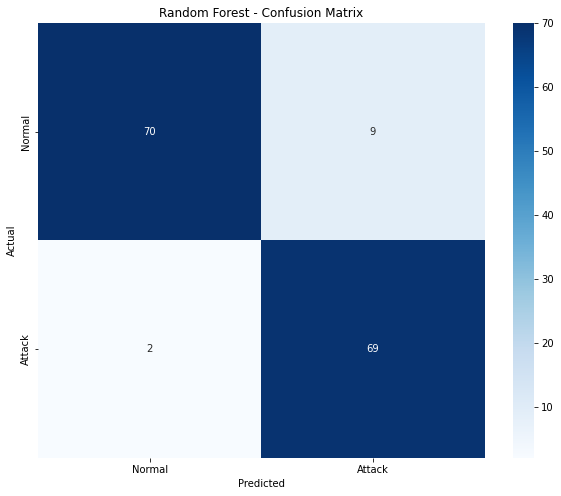

Accuracy   : 92.67%
Precision  : 88.46%
Recall     : 97.18%


In [99]:

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

X, y = make_classification(n_samples=500, n_features=10, n_classes=2, random_state=42)

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

#  Predictions
y_pred = rf_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy   : {acc*100:.2f}%")
print(f"Precision  : {prec*100:.2f}%")
print(f"Recall     : {rec*100:.2f}%")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Assume X_b and y_b are your features and labels
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

# Train models
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
dt_res = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

models = {"Logistic Regression": lr, "Decision Tree": dt_res, "Random Forest": rf}

for model in models.values():
    model.fit(X_train, y_train)

# Number of classes
n_classes = len(np.unique(y_b))

# Binarize labels
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Initialize plot
plt.figure(figsize=(12, 7))
all_fpr = np.linspace(0, 1, 100)
for name, model in models.items():
    y_score = model.predict_proba(X_test)

    fpr_dict = dict()
    tpr_dict = dict()
    auc_dict = dict()
    tprs_interp = []

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
        tprs_interp.append(np.interp(all_fpr, fpr_dict[i], tpr_dict[i]))

    # Compute macro-average
    mean_tpr = np.mean(tprs_interp, axis=0)
    mean_auc = auc(all_fpr, mean_tpr)

    # Thicker line for Decision Tree
    lw = 5 if name == "Decision Tree" else 2.5
    plt.plot(all_fpr, mean_tpr, lw=lw, label=f"{name} (Macro AUC = {mean_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
